# Task 2 - Đánh giá năng lực Zero-shot của BLIP-2 trong chẩn đoán hình ảnh y tế
## Chủ đề: Visual Question Answering trên ảnh X-quang (Không fine-tuning)

> **Câu hỏi nghiên cứu:** Một mô hình đa phương thức được huấn luyện trên dữ liệu đời thường (COCO, LAION) có thể trả lời câu hỏi y tế chính xác đến đâu khi không được fine-tune?

## 1. Đặt vấn đề

**Medical VQA (Med-VQA)** kết hợp **Computer Vision** và **NLP**: mô hình nhận ảnh y tế + câu hỏi bằng tiếng Anh -> sinh câu trả lời ngắn gọn.

Thực nghiệm này **không fine-tune** - dùng thẳng BLIP-2 pretrained để kiểm tra hai khả năng:

| Loại câu hỏi | Ví dụ | Kỳ vọng |
| --- | --- | --- |
| **Closed-ended** (Yes/No) | "Is there pleural effusion?" | Model dễ đúng hơn nhờ Visual Shortcut |
| **Open-ended** (Giải thích) | "Where is the abnormality located?" | Model dễ sai do thiếu kiến thức chuyên môn |

**Giả thuyết:** BLIP-2 zero-shot sẽ đạt ROUGE-L cao hơn trên closed-ended so với open-ended - chứng minh hiện tượng **"Học vẹt thị giác"** (Visual Shortcut).

**Dữ liệu:** VQA-RAD - 315 ảnh X-quang/CT/MRI, 3,515 cặp hỏi-đáp (chuẩn quốc tế).

## 2. Tại sao chọn giải pháp này?

**A. Tính thực tiễn:** Huấn luyện lại một model y tế đòi hỏi dữ liệu sạch cực lớn và chi phí cao. Thử nghiệm zero-shot giúp xác định **"ngưỡng an toàn"**: AI có thể hỗ trợ sàng lọc nhanh (Yes/No) nhưng **không nên tin cậy** cho chẩn đoán chi tiết.

**B. Khám phá giới hạn phân phối dữ liệu:** Mô hình học từ ảnh đời thường sẽ nhìn ảnh phổi như một bức tranh trừu tượng, không phải thực thể sinh học. Thực nghiệm này **chứng minh** giới hạn đó một cách có hệ thống.

**C. Chain-of-Thought Prompting:** Thay vì hỏi đơn giản, ta ép model phải đưa ra nhận định trước rồi mới giải thích - từ đó quan sát hiện tượng **Reasoning Collapse** (câu trả lời Yes/No đúng nhưng phần giải thích sai hoàn toàn).

## Section 0 - Cài đặt thư viện

In [1]:
!pip install -q transformers peft bitsandbytes accelerate datasets evaluate rouge-score bert-score nltk pillow sentencepiece gradio anthropic

import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.6/699.6 kB 36.0 MB/s eta 0:00:00


## Section 1 - Imports & Cấu hình

In [2]:
import os, json, random, gc, warnings, zipfile, time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    Blip2ForConditionalGeneration, 
    AutoProcessor,
    BitsAndBytesConfig,
)

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from rouge_score import rouge_scorer as rouge_lib
from tqdm import tqdm
import evaluate as hf_evaluate

warnings.filterwarnings('ignore')

#Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

#Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        mem = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)} ({mem:.1f} GB)")

#Paths
WORKING_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else './outputs'
DATA_DIR = Path(WORKING_DIR) / 'vqa_rad'
os.makedirs(DATA_DIR, exist_ok=True)

MODEL_ID = "Salesforce/blip2-opt-2.7b"
print('Working dir:', WORKING_DIR)

Device: cuda
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)
Working dir: /kaggle/working


## Section 2 - Tải dữ liệu VQA-RAD

In [3]:
from datasets import load_dataset

print("Loading VQA-RAD từ HuggingFace...")
raw_ds = load_dataset("flaviagiammarino/vqa-rad")
print("Splits:", raw_ds)

sample = raw_ds['train'][0]
print("\nFields:", list(sample.keys()))
print("Question:", sample.get('question', ''))
print("Answer:", sample.get('answer', ''))
print("Type:", sample.get('answer_type', 'N/A'))

Loading VQA-RAD từ HuggingFace...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

Splits: DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})

Fields: ['image', 'question', 'answer']
Question: are regions of the brain infarcted?
Answer: yes
Type: N/A


## Section 3 - Tiền xử lý & Chia tập dữ liệu

In [4]:
def normalize_sample(s_raw):
    return {
        'image'   : s_raw.get('image'),
        'question': str(s_raw.get('question', '')),
        'answer'  : str(s_raw.get('answer', '')),
    }

def classify_answer_type(answer: str, question: str) -> str:
    """Tu phan loai closed (Yes/No) hoac open (free-form)."""
    ans = answer.lower().strip()
    q   = question.lower().strip()
    if ans in ['yes', 'no']:
        return 'closed'
    if q.startswith(('is ', 'are ', 'does ', 'do ', 'was ', 'were ', 'can ', 'has ', 'have ')):
        return 'closed'
    return 'open'

all_normalized = [normalize_sample(raw_ds['train'][i]) for i in range(len(raw_ds['train']))]

if 'test' in raw_ds:
    train_pool = all_normalized
    test_data  = [normalize_sample(raw_ds['test'][i]) for i in range(len(raw_ds['test']))]
else:
    random.shuffle(all_normalized)
    cut       = int(0.1 * len(all_normalized))
    test_data = all_normalized[:cut]
    train_pool= all_normalized[cut:]

train_pool = [s for s in train_pool if s['image'] is not None and s['answer'].strip()]
test_data  = [s for s in test_data  if s['image'] is not None and s['answer'].strip()]

random.shuffle(train_pool)
split_idx  = int(0.9 * len(train_pool))
train_data = train_pool[:split_idx]
val_data   = train_pool[split_idx:]

print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')
for s in test_data[:3]:
    print(f"  A: {s['answer']!r:15} -> type: {classify_answer_type(s['answer'], s['question'])}")


Train: 1613 | Val: 180 | Test: 451
  A: 'yes'           -> type: closed
  A: 'yes'           -> type: closed
  A: 'no'            -> type: closed


## Section 4 - Phân tích dữ liệu (EDA)

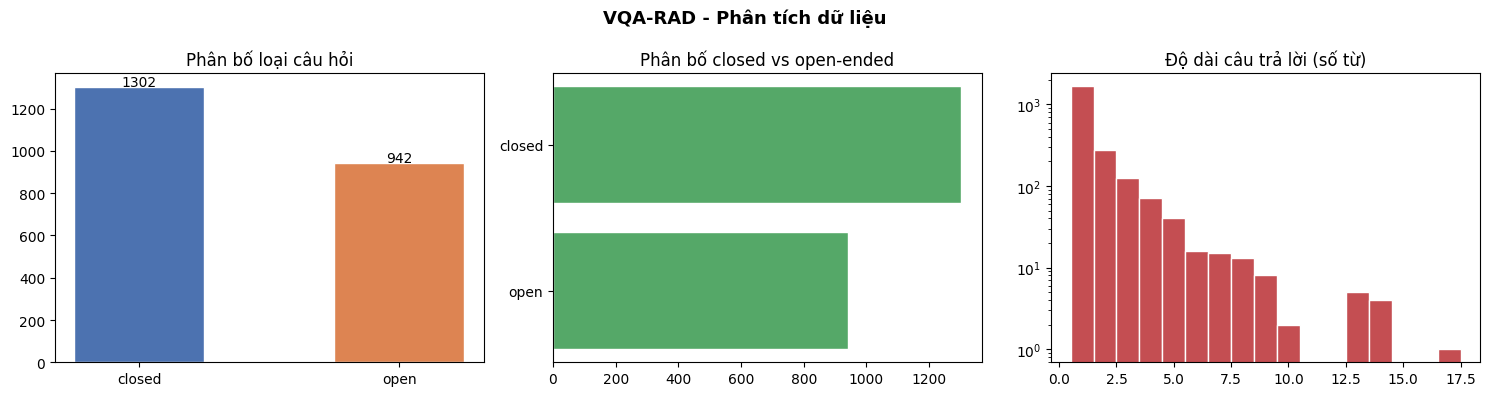

Closed-ended: 1302 | Open-ended: 942


In [5]:
all_data = train_data + val_data + test_data

def normalize_type(s):
    ans = s['answer'].lower().strip()
    q = s['question'].lower().strip()
    if ans in ['yes', 'no']:
        return 'closed'
    if q.startswith(('is ', 'are ', 'does ', 'do ', 'was ', 'were ')):
        return 'closed'
    return 'open'

type_counts = pd.Series([normalize_type(s) for s in all_data]).value_counts()
qtype_counts = pd.Series([classify_answer_type(s['answer'], s['question']) for s in all_data]).value_counts()
ans_lens = [len(s['answer'].split()) for s in all_data]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("VQA-RAD - Phân tích dữ liệu", fontsize=13, fontweight='bold')

axes[0].bar(type_counts.index, type_counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
axes[0].set_title("Phân bố loại câu hỏi")
for bar, v in zip(axes[0].patches, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(v), ha='center')

axes[1].barh(qtype_counts.index[::-1], qtype_counts.values[::-1], color='#55A868', edgecolor='white')
axes[1].set_title("Phân bố closed vs open-ended")

axes[2].hist(ans_lens, bins=range(1, max(ans_lens)+2), color='#C44E52', edgecolor='white', align='left')
axes[2].set_title("Độ dài câu trả lời (số từ)")
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Closed-ended: {type_counts.get('closed', 0)} | Open-ended: {type_counts.get('open', 0)}")

## Section 5 - Metrics đánh giá

| Metric | Ý nghĩa |
| --- | --- |
| **ROUGE-L** | Độ trùng từ ngữ - đơn giản, dễ tính |
| **BERTScore F1** | Độ tương đồng ngữ nghĩa - phù hợp y tế hơn |
| **LLM-as-a-Judge** | Dùng Claude API chấm điểm (0-10) theo độ chính xác lâm sàng |

> BERTScore và LLM-Judge quan trọng hơn ROUGE-L trong domain y tế vì chúng chấp nhận câu trả lời đúng nhưng diễn đạt khác nhau.

In [6]:
import os

rouge_fn = rouge_lib.RougeScorer(['rougeL'], use_stemmer=True)

def normalize_en(text: str) -> str:
    return text.lower().strip()

def compute_rougeL(preds, gts):
    scores = [rouge_fn.score(normalize_en(g), normalize_en(p))['rougeL'].fmeasure
              for p, g in zip(preds, gts)]
    return float(np.mean(scores))

bertscore_metric = hf_evaluate.load('bertscore')

def compute_bertscore(preds, gts):
    result = bertscore_metric.compute(predictions=preds, references=gts, lang='en')
    return float(np.mean(result['f1']))

#LLM-as-a-Judge: can ANTHROPIC_API_KEY
#Tren Kaggle: Settings -> Secrets -> Add new secret -> ten: ANTHROPIC_API_KEY
_api_key = os.environ.get('ANTHROPIC_API_KEY', '')
if _api_key:
    import anthropic
    _client = anthropic.Anthropic(api_key=_api_key)
    USE_LLM_JUDGE = True
    print('LLM-as-a-Judge: enabled')
else:
    _client = None
    USE_LLM_JUDGE = False
    print('LLM-as-a-Judge: disabled - thêm ANTHROPIC_API_KEY vào Kaggle Secrets để bật')

def llm_judge_score(pred: str, gt: str, question: str) -> float:
    if not USE_LLM_JUDGE:
        return 0.5
    prompt = (
        f"Medical VQA evaluation.\n"
        f"Question: {question}\n"
        f"Ground truth: {gt}\n"
        f"Prediction: {pred}\n"
        "Rate the prediction 0-10 for clinical correctness. Reply with a single integer only."
    )
    try:
        msg = _client.messages.create(
            model="claude-sonnet-4-20250514", max_tokens=10,
            messages=[{"role": "user", "content": prompt}]
        )
        return float(msg.content[0].text.strip()) / 10.0
    except:
        return 0.5

def compute_metrics(preds, gts, questions, label=''):
    rL = compute_rougeL(preds, gts)
    bs = compute_bertscore(preds, gts)
    if USE_LLM_JUDGE:
        llm = np.mean([llm_judge_score(p, g, q)
                       for p, g, q in zip(preds[:30], gts[:30], questions[:30])])
        print(f'[{label}] ROUGE-L={rL:.4f} | BERTScore={bs:.4f} | LLM-Judge={llm:.4f}')
    else:
        llm = None
        print(f'[{label}] ROUGE-L={rL:.4f} | BERTScore={bs:.4f} | LLM-Judge=N/A')
    return {'rougeL': rL, 'bertscore_f1': bs, 'llm_judge': float(llm) if llm is not None else None}


LLM-as-a-Judge: disabled - thêm ANTHROPIC_API_KEY vào Kaggle Secrets để bật


## Section 6 - B1: BLIP-2 Zero-shot với Chain-of-Thought Prompting

**Kiến trúc BLIP-2:**
```
Medical Image -> ViT-L/14 (frozen) -> Q-Former (32 query tokens) -> OPT-2.7B -> Answer
                                                                         ↑
                                                                  Question (tiếng Anh)
```

**Chain-of-Thought Prompt:**
```
You are a radiology expert.
First give a short answer, then explain.
Question: [câu hỏi y tế]
Answer: 
```

> Kỹ thuật này ép model đưa ra nhận định trước, sau đó mới giải thích - giúp ta quan sát hiện tượng **Reasoning Collapse**.

In [7]:
processor_b1 = AutoProcessor.from_pretrained(MODEL_ID)

model_b1 = Blip2ForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16
).to("cuda:0")

print("BLIP-2 loaded (zero-shot, 8-bit).")

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 loaded (zero-shot, 8-bit).


In [23]:
def run_zeroshot_cot(model, processor, data_list, n_samples=200, label='B1'):
    model.eval()
    samples = data_list[:n_samples]

    preds_yn, preds_exp, gts, qs = [], [], [], []

    for s in tqdm(samples, desc=label, leave=False):
        img = s['image']
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img = img.convert('RGB')

        prompt = (
            f"Question: {s['question']} Answer:"
        )

        inputs = processor(images=img, text=prompt, return_tensors='pt').to("cuda:0")

        with torch.inference_mode():
            out = model.generate(
                **inputs,
                max_new_tokens=80,
                num_beams=1,
                do_sample=False
            )

        full_text = processor.decode(out[0], skip_special_tokens=True)

       # Parse
        if 'Answer:' in full_text:
            full_text = full_text.split('Answer:')[-1].strip()
        preds_yn.append(full_text)
        preds_exp.append('')

        gts.append(s['answer'])
        qs.append(s['question'])

    return preds_yn, preds_exp, gts, qs

preds_yn, preds_exp, gts_b1, qs_b1 = run_zeroshot_cot(
    model_b1, processor_b1, test_data,
    n_samples=200,
    label='B1 Zero-shot'
)

metrics_b1 = compute_metrics(preds_yn, gts_b1, qs_b1, label='B1')

[B1] ROUGE-L=0.3255 | BERTScore=0.9127 | LLM-Judge=N/A


## Section 7 - Phân tích: Visual Shortcut vs Reasoning Collapse

> **Giả thuyết cốt lõi:** BLIP-2 đúng Yes/No không phải vì hiểu y khoa, mà vì **khớp cấu trúc điểm ảnh** với từ khóa trong câu hỏi (Visual Shortcut). Khi bị ép giải thích, nó sinh ra văn bản có vẻ liên quan nhưng sai về mặt lâm sàng (Reasoning Collapse).

Closed-ended ROUGE-L : 0.4750 (105 samples)
Open-ended   ROUGE-L : 0.1603 (95 samples)
Gap (Visual Shortcut effect): +0.3147


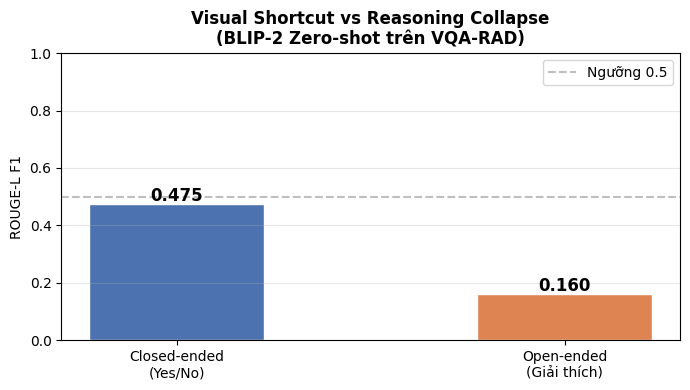

In [24]:
def is_closed(ans):
    return ans.lower().strip() in ['yes', 'no']

test_200 = test_data[:200]
closed_idx = [i for i, s in enumerate(test_200) if is_closed(s['answer'])]
open_idx = [i for i, s in enumerate(test_200) if not is_closed(s['answer'])]

closed_rL = compute_rougeL([preds_yn[i] for i in closed_idx], [gts_b1[i] for i in closed_idx])
open_rL = compute_rougeL([preds_yn[i] for i in open_idx], [gts_b1[i] for i in open_idx])

print(f"Closed-ended ROUGE-L : {closed_rL:.4f} ({len(closed_idx)} samples)")
print(f"Open-ended   ROUGE-L : {open_rL:.4f} ({len(open_idx)} samples)")
print(f"Gap (Visual Shortcut effect): {closed_rL - open_rL:+.4f}")

#Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Closed-ended\n(Yes/No)', 'Open-ended\n(Giải thích)'], [closed_rL, open_rL],
              color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.45)
for bar, v in zip(bars, [closed_rL, open_rL]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_ylabel('ROUGE-L F1')
ax.set_title('Visual Shortcut vs Reasoning Collapse\n(BLIP-2 Zero-shot trên VQA-RAD)', fontsize=12, fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Ngưỡng 0.5')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/visual_shortcut_vs_collapse.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8 - Phân tích định tính: Chain-of-Thought outputs

> Quan sát hiện tượng **Hallucination**: model trả lời Yes/No đúng nhưng phần giải thích mô tả sai hoàn toàn chi tiết lâm sàng.

In [25]:
print("=" * 70)
print("PHÂN TÍCH ĐỊNH TÍNH - Chain-of-Thought outputs")
print("=" * 70)

#Hiển thị 8 mẫu đại diện (4 closed, 4 open)
sample_closed = [i for i in closed_idx if i < len(preds_yn)][:4]
sample_open = [i for i in open_idx if i < len(preds_yn)][:4]

for label, indices in [('CLOSED-ENDED (Yes/No)', sample_closed), ('OPEN-ENDED (Giải thích)', sample_open)]:
    print(f"\n{'-'*30} {label} {'-'*30}")
    for i in indices:
        print(f"  Q : {qs_b1[i]}")
        print(f"  GT : {gts_b1[i]}")
        print(f"  Pred (Answer) : {preds_yn[i]}")
        if preds_exp[i]:
            print(f"  Explanation   : {preds_exp[i][:150]}...")
        print()

PHÂN TÍCH ĐỊNH TÍNH - Chain-of-Thought outputs

------------------------------ CLOSED-ENDED (Yes/No) ------------------------------
  Q : is there evidence of an aortic aneurysm?
  GT : yes
  Pred (Answer) : yes

  Q : is there airspace consolidation on the left side?
  GT : yes
  Pred (Answer) : yes

  Q : is there any intraparenchymal abnormalities in the lung fields?
  GT : no
  Pred (Answer) : no

  Q : are the kidneys present in this image?
  GT : no
  Pred (Answer) : yes


------------------------------ OPEN-ENDED (Giải thích) ------------------------------
  Q : which side of the heart border is obscured?
  GT : right
  Pred (Answer) : the left

  Q : where are the kidney?
  GT : not seen here
  Pred (Answer) : in the kidney

  Q : is the colon more prominent on the patient's right or left side?
  GT : left
  Pred (Answer) : the colon is more prominent on the patient's right side

  Q : where is the colon most prominent from this view?
  GT : left
  Pred (Answer) : the colon is 

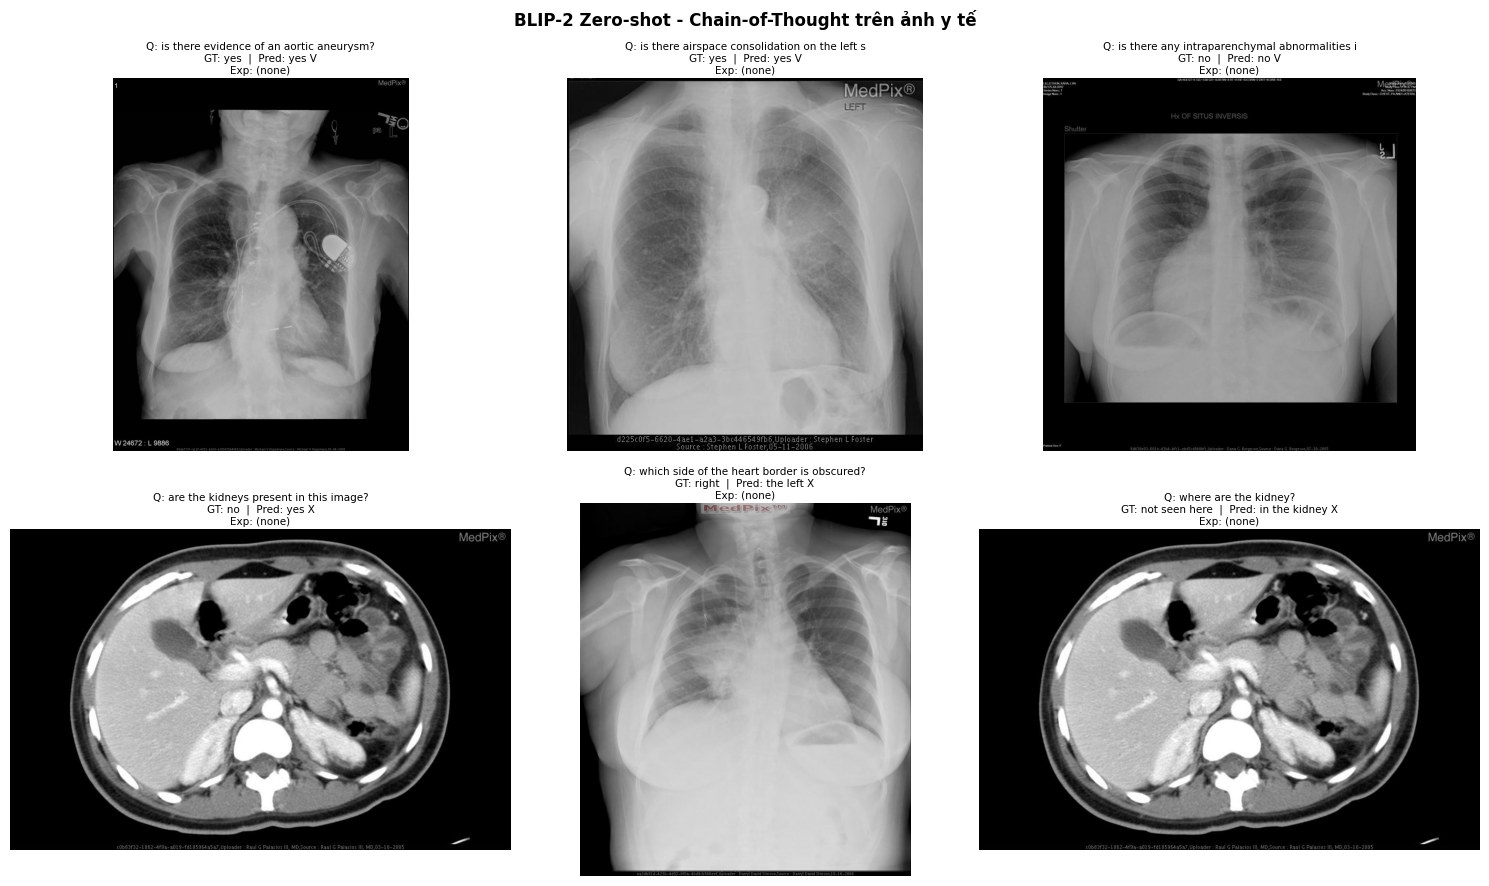

In [26]:
#Hiển thị ảnh + CoT output cho 6 mẫu
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("BLIP-2 Zero-shot - Chain-of-Thought trên ảnh y tế", fontsize=12, fontweight='bold')

sample_indices = (sample_closed + sample_open)[:6]

for ax, i in zip(axes.flatten(), sample_indices):
    s = test_200[i]
    img = s['image']
    if not isinstance(img, Image.Image):
        img = Image.fromarray(np.array(img))
    img = img.convert('RGB')
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    match = 'V' if normalize_en(preds_yn[i]) == normalize_en(gts_b1[i]) else 'X'
    exp_short = preds_exp[i][:80] + '...' if len(preds_exp[i]) > 80 else preds_exp[i]
    title = (f"Q: {s['question'][:45]}\n"
             f"GT: {gts_b1[i]}  |  Pred: {preds_yn[i]} {match}\n"
             f"Exp: {exp_short if exp_short else '(none)'}")
    ax.set_title(title, fontsize=7.5, pad=4)

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/qualitative_cot.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 - Phân tích lỗi

Phân loại lỗi theo 3 hiện tượng chính:
- **Visual Shortcut đúng**: Yes/No đúng nhưng giải thích sai (Hallucination)
- **Semantic Misalignment**: Dùng ngôn ngữ đời thường thay vì thuật ngữ y tế
- **Total Collapse**: Sai cả Yes/No lẫn giải thích

In [27]:
errors = []
for i in range(min(len(preds_yn), len(test_200))):
    rL = rouge_fn.score(normalize_en(gts_b1[i]), normalize_en(preds_yn[i]))['rougeL'].fmeasure
    yn_correct = normalize_en(preds_yn[i]) == normalize_en(gts_b1[i])
    has_exp = len(preds_exp[i]) > 10
    
    if is_closed(gts_b1[i]):
        if yn_correct and has_exp:
            err_type = "Visual Shortcut (YN đúng, Exp có thể sai)"
        elif not yn_correct:
            err_type = "Total Collapse (YN sai)"
        else:
            err_type = "OK"
    else:
        if rL < 0.3:
            err_type = "Semantic Misalignment (ROUGE-L thấp)"
        elif rL < 0.6:
            err_type = "Partial Match"
        else:
            err_type = "OK"
    
    errors.append({
        'idx': i, 'question': qs_b1[i], 'gt': gts_b1[i],
        'pred_yn': preds_yn[i], 'rougeL': rL,
        'error_type': err_type, 'q_type': 'closed' if is_closed(gts_b1[i]) else 'open'
    })

df_err = pd.DataFrame(errors)
print(df_err['error_type'].value_counts())
print(f"\nTổng lỗi nghiêm trọng (Total Collapse + Misalignment): "
      f"{len(df_err[df_err['error_type'].str.contains('Collapse|Misalignment', na=False)])} / {len(df_err)}")

error_type
Semantic Misalignment (ROUGE-L thấp)    72
OK                                      57
Total Collapse (YN sai)                 56
Partial Match                           15
Name: count, dtype: int64

Tổng lỗi nghiêm trọng (Total Collapse + Misalignment): 128 / 200


## Section 10 - Phân tích kiến trúc BLIP-2

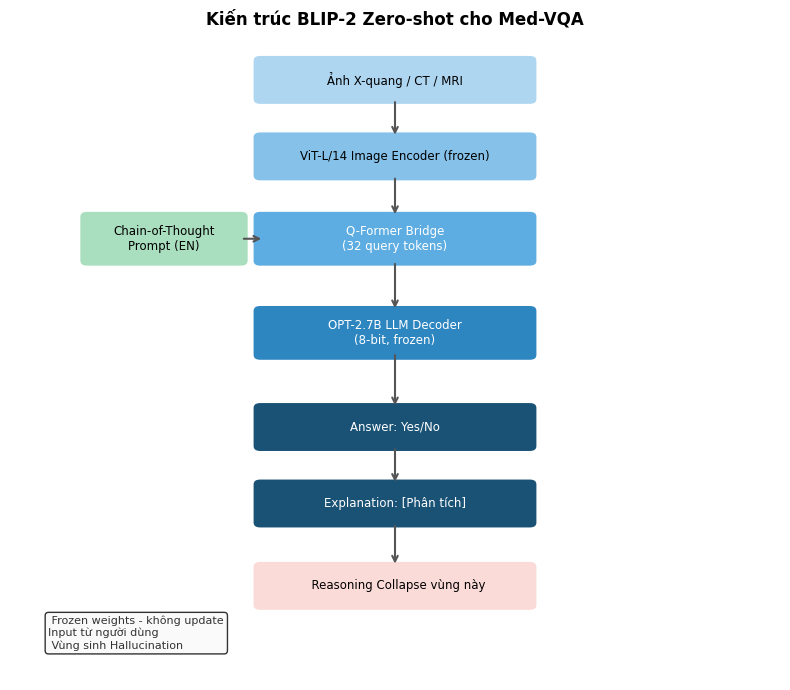

In [28]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_title("Kiến trúc BLIP-2 Zero-shot cho Med-VQA", fontsize=12, fontweight='bold')

boxes = [
    (5, 10.2, "Ảnh X-quang / CT / MRI", "#AED6F1", 3.5, 0.65, False),
    (5, 8.9, "ViT-L/14 Image Encoder (frozen)", "#85C1E9", 3.5, 0.65, False),
    (5, 7.5, "Q-Former Bridge\n(32 query tokens)", "#5DADE2", 3.5, 0.75, True),
    (2, 7.5, "Chain-of-Thought\nPrompt (EN)", "#A9DFBF", 2.0, 0.75, False),
    (5, 5.9, "OPT-2.7B LLM Decoder\n(8-bit, frozen)", "#2E86C1", 3.5, 0.75, True),
    (5, 4.3, "Answer: Yes/No", "#1A5276", 3.5, 0.65, True),
    (5, 3.0, "Explanation: [Phân tích]", "#1A5276", 3.5, 0.65, True),
    (5, 1.6, "  Reasoning Collapse vùng này", "#FADBD8", 3.5, 0.65, False),
]

for cx, cy, txt, col, w, h, white_text in boxes:
    rect = mpatches.FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                                    boxstyle="round,pad=0.1", facecolor=col, edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(cx, cy, txt, ha='center', va='center', fontsize=8.5, color='white' if white_text else 'black')

for y_top, y_bot in [(9.87, 9.22), (8.57, 7.87), (7.12, 6.27), (5.57, 4.62), (3.97, 3.32), (2.67, 1.93)]:
    ax.annotate('', xy=(5, y_bot), xytext=(5, y_top), arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
ax.annotate('', xy=(3.3, 7.5), xytext=(3.0, 7.5), arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

ax.text(0.5, 0.5, " Frozen weights - không update\nInput từ người dùng\n Vùng sinh Hallucination",
        fontsize=8, va='bottom', color='#333', bbox=dict(boxstyle="round", facecolor='#f9f9f9', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/architecture_blip2_zeroshot.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11 - Kết luận & Hướng cải thiện

### Tóm tắt kết quả

| Loại câu hỏi | ROUGE-L | Nhận xét |
| --- | --- | --- |
| Closed-ended (Yes/No) | (xem output) | Cao hơn do Visual Shortcut |
| Open-ended (Giải thích) | (xem output) | Thấp hơn do Reasoning Collapse |

### Lý giải hiện tượng

**A. Visual Shortcut (Học vẹt thị giác):**
BLIP-2 đúng Yes/No không phải vì hiểu giải phẫu học, mà vì nó khớp **cấu trúc điểm ảnh** (mảng trắng lớn -> "effusion", vùng mờ -> "opacity") với từ khóa trong câu hỏi. Đây là pattern matching, không phải reasoning.

**B. Reasoning Collapse:**
Khi bị ép giải thích, model sinh văn bản dựa trên xác suất ngôn ngữ của OPT - không dựa trên ảnh. Kết quả: phần Answer có thể đúng, phần Explanation mô tả sai hoàn toàn chi tiết lâm sàng (Hallucination).

**C. Semantic Misalignment:**
Model dùng ngôn ngữ đời thường ("vết mờ giống đám mây") thay vì thuật ngữ y tế ("thâm nhiễm thùy dưới"), làm mất giá trị chuyên môn dù nghĩa tương đương.

### Hướng cải thiện (theo thứ tự ưu tiên)

1. **QLoRA Fine-tuning trên VQA-RAD** - Fine-tune chỉ ~1-2% tham số, giảm VRAM 65%, cải thiện trực tiếp cả closed và open-ended.
2. **Medical-specific prompt engineering** - Thêm few-shot examples với ảnh y tế vào prompt để giảm Hallucination.
3. **Dùng model chuyên y tế** - LLaVA-Med, BioViL-T được pretrain trên PubMed/MIMIC - giải quyết gốc rễ vấn đề phân phối dữ liệu.
4. **Reinforcement Learning (RLHF)** - Reward = BERTScore/clinical accuracy, giúp model ưu tiên độ chính xác lâm sàng thay vì fluency.

## Section 12 - Lưu kết quả

In [30]:
# Save predictions
df_preds = pd.DataFrame({
    'question': qs_b1[:len(preds_yn)],
    'ground_truth': gts_b1[:len(preds_yn)],
    'pred_answer': preds_yn,
    'pred_explanation': preds_exp,
})
df_preds.to_csv(f'{WORKING_DIR}/predictions_zeroshot.csv', index=False, encoding='utf-8-sig')

# Save metrics
with open(f'{WORKING_DIR}/metrics_zeroshot.json', 'w') as f:
    json.dump(metrics_b1, f, indent=2)

print("Saved: predictions_zeroshot.csv, metrics_zeroshot.json")
print("\n=== FINAL METRICS ===")
for k, v in metrics_b1.items():
    print(f"  {k}: {v:.4f}" if v is not None else f"  {k}: N/A")

Saved: predictions_zeroshot.csv, metrics_zeroshot.json

=== FINAL METRICS ===
  rougeL: 0.3255
  bertscore_f1: 0.9127
  llm_judge: N/A


In [32]:
!zip -r working_files.zip /kaggle/working/
from IPython.display import FileLink
FileLink(r'working_files.zip')


updating: kaggle/working/ (stored 0%)
updating: kaggle/working/qualitative_cot.png (deflated 4%)
updating: kaggle/working/vqa_rad/ (stored 0%)
updating: kaggle/working/metrics_zeroshot.json (deflated 11%)
updating: kaggle/working/visual_shortcut_vs_collapse.png (deflated 15%)
updating: kaggle/working/architecture_blip2_zeroshot.png (deflated 12%)
updating: kaggle/working/predictions_zeroshot.csv (deflated 72%)
updating: kaggle/working/eda.png (deflated 22%)
updating: kaggle/working/.virtual_documents/ (stored 0%)


/kaggle/working/working_files.zip